In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/final_forecast_dataset.csv"
)

df.head()

,Agmt Id,Cust Age,Cust Gender,Cust Cibil Score,Cust Employment Type,Cust Net Salary,Coborrower Flag,App Score Risk,Agmt Date,Seizure Date,...,Asset Accident Flag,Traiffic Challan Amount,Target Sold Amount At Liquidation,Asset_Health_Index,Recovery_Efficiency_Index,LGD,LGD_pct,Depreciation_Pct,Asset_Age_Group,Residual_Value_Forecast
0,ASSET_1,29,F,-1,NREGI,30000,N,LOW RISK,2023-12-27,2025-05-23,...,No,0,37000.0,100.0,78.834107,9934.0,21.165893,54.320988,1-2 Years,31061.247508
1,ASSET_2,24,M,-1,NREGI,60000,N,LOW RISK,2025-11-20,2026-05-31,...,No,0,56000.0,100.0,65.745448,29177.0,34.254552,47.565543,0-1 Year,49192.500708
2,ASSET_3,32,F,763,AGR,29500,N,LOW RISK,2024-05-16,2025-06-24,...,No,0,40500.0,70.0,78.369754,11178.1,21.630246,49.783013,1-2 Years,35015.205663
3,ASSET_4,25,F,-1,NREGI,40000,N,MEDIUM RISK,2025-10-24,2026-04-30,...,No,0,49000.0,70.0,74.384431,16874.0,25.615569,40.606061,0-1 Year,38754.405520
4,ASSET_5,59,F,653,SAL,45000,N,MEDIUM RISK,2024-09-20,2025-05-30,...,No,0,46000.0,100.0,69.099157,20571.0,30.900843,44.242424,0-1 Year,40817.718654


1. Residual Loss

How much value the asset lost.

In [13]:
df["Residual_Loss"] = (
    df["Asset Cost At Disbursal"]
    - df["Residual_Value_Forecast"]
)

2. Residual Risk Score

Normalize into percentage.

In [14]:
df["Residual_Risk_Score"] = (
    df["Residual_Loss"]
    /
    df["Asset Cost At Disbursal"]
) * 100

df["Residual_Risk_Score"] = (
    df["Residual_Risk_Score"]
    .clip(0,100)
)

In [15]:
df["Residual_Risk_Score"].describe()

count    15000.000000
mean        60.683082
std          8.127844
min          8.540692
25%         55.700107
50%         61.084390
75%         66.265819
max         90.634437
Name: Residual_Risk_Score, dtype: float64

3. Dynamic Risk Bands

In [16]:
q1 = df["Residual_Risk_Score"].quantile(0.25)
q2 = df["Residual_Risk_Score"].quantile(0.50)
q3 = df["Residual_Risk_Score"].quantile(0.75)

print(q1,q2,q3)

55.70010721968268 61.084389925873104 66.26581879740728


In [17]:
def risk_band(score):

    if score <= q1:
        return "Low"

    elif score <= q2:
        return "Medium"

    elif score <= q3:
        return "High"

    else:
        return "Critical"

In [18]:
df["Risk_Band"] = (
    df["Residual_Risk_Score"]
    .apply(risk_band)
)

In [19]:
df["Risk_Band"].value_counts()

Risk_Band
High        3750
Low         3750
Medium      3750
Critical    3750
Name: count, dtype: int64

4. Portfolio Risk Score

In [20]:
portfolio_risk = (
    df["Residual_Risk_Score"]
    .mean()
)

print(portfolio_risk)

60.68308159582042


5. Segment Risk Index

In [21]:
segment_risk = (
    df.groupby("Asset Fuel Type")
    ["Residual_Risk_Score"]
    .mean()
    .sort_values(ascending=False)
)

segment_risk

Asset Fuel Type
Petrol    60.757846
EV        57.092914
Name: Residual_Risk_Score, dtype: float64

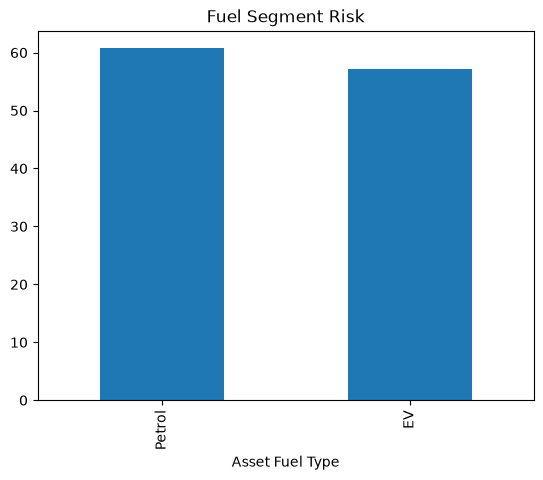

In [22]:
segment_risk.plot(
    kind="bar"
)

plt.title("Fuel Segment Risk")
plt.show()

6. State Risk Index

In [23]:
state_risk = (
    df.groupby("Cust State")
    ["Residual_Risk_Score"]
    .mean()
    .sort_values(ascending=False)
)

state_risk.head(10)

Cust State
ML    67.777984
HR    65.078928
DL    64.965458
BR    64.843873
TR    64.594285
AR    64.568935
MP    64.306692
UP    64.181935
JH    63.900195
MH    63.740818
Name: Residual_Risk_Score, dtype: float64

7. Model Risk Index

In [24]:
model_risk = (
    df.groupby("Asset Model")
    ["Residual_Risk_Score"]
    .mean()
    .sort_values(ascending=False)
)

model_risk.head(20)

Asset Model
CITY PLUS    65.922898
SPORT        65.240609
RAIDER       63.134059
NTORQ        62.973401
STAR CITY    62.546479
RADEON       61.988554
RONIN        61.969546
PEP          60.465931
APACHE       59.911155
MOPEDS       58.566864
JUPITER      58.069301
TVS          57.092914
ZEST         47.321102
Name: Residual_Risk_Score, dtype: float64

8. Profitability Score

In [25]:
df["Profitability_Score"] = (

    (df["Cust Net IRR"] * 10)

    +

    (100 - df["Residual_Risk_Score"])

)

normalise:

In [26]:
df["Profitability_Score"] = (
    (
        df["Profitability_Score"]
        -
        df["Profitability_Score"].min()
    )
    /
    (
        df["Profitability_Score"].max()
        -
        df["Profitability_Score"].min()
    )
) * 100

In [27]:
df["Profitability_Score"].describe()

count    15000.000000
mean        50.250855
std         11.366181
min          0.000000
25%         43.978259
50%         51.089513
75%         57.273949
max        100.000000
Name: Profitability_Score, dtype: float64

In [28]:
df.to_csv(
    "../data/processed/risk_scored_dataset.csv",
    index=False
)

print("Risk Dataset Saved")

Risk Dataset Saved
